# HEADER #
Authors: 

Alexandre Costa, alexandre.torres-costa@universite-paris-saclay.fr

Francesc CRESPÍ, francesc.serra-crespi@universite-paris-saclay.fr

In [1]:
import pandas as pd
import spacy

# NLP Today — Session 1: PoS Tagging and Constituency Parsing


| Notebook section | Report section | Question it answers |
|---|---|---|
| Part 1 — Manual analysis | First part | What tags and what grammar do *we* propose, and what trees do they produce? |
| Part 2 — Automatic analysis | Second part | What do spaCy / sciSpaCy produce, how good is it, and how do their errors propagate to parsing? |
| Part 3 — Observations | Third part | What do we conclude from the comparison? |


## 0. Dataset

The six sentences of the assignment:

- four from the general domain (chosen for their syntactic ambiguity)
- two from specialty domains (biology and astronomy)

**Manual gold-standard PoS annotation**, using the Universal Dependencies tagset.(<https://universaldependencies.org/u/pos/>).

In [2]:
data = pd.read_csv("data/sentences.csv", sep=";")
data["n_tokens"] = data["Tokens"].str.split().str.len()
data[["Domain", "Sentence", "n_tokens"]]

,Domain,Sentence,n_tokens
0,General,The cat sat on the couch.,7
1,General,Time flies like an arrow.,6
2,General,The spy saw the cop with the telescope.,9
3,General,The spy saw the cop with the revolver.,9
4,Specialty,Arabidopsis thaliana seedlings exhibit longer ...,21
5,Specialty,A spectrogram of PSN J10354824+3900279 obtaine...,25


# Part 1 — Manual analysis

## 1.1 Gold-standard PoS annotation

The table below is the reference against which both automatic taggers will be scored in Part 2.
Three decisions were not obvious, and we record why we made them:

* **`Arabidopsis thaliana` → `PROPN PROPN`.** We treated the binomial as a name, not a description,
  and tagged both tokens alike — including the lowercase *thaliana*, since a multiword name carries
  the tag across all of its tokens. The competing reading is that a species is a *kind* and so a
  common noun; we return to it in Part 3.

* **`longer` → `ADJ`.** In *exhibit longer hypocotyls* it modifies the noun *hypocotyls*, not the
  verb, so we read it as a comparative adjective rather than an adverb.

* **`they`, `which`, `this` → `PRON`.** Each stands in for a noun phrase instead of introducing one;
  we reserved `DET` for the determiner slot (*which seedlings*, *this temperature*), where a noun
  follows.

In [3]:
# GOLD   : sentence -> list of gold PoS tags
# TOKENS : sentence -> our tokenisation
GOLD, TOKENS = {}, {}

for _, row in data.iterrows():
    GOLD[row["Sentence"]] = row["Pos"].split()
    TOKENS[row["Sentence"]] = row["Tokens"].split()

TAGSET = ["ADJ", "ADP", "AUX", "DET", "NOUN", "NUM", "PRON", "PROPN", "PUNCT", "SCONJ",
          "SYM", "VERB"]

assert all(t in TAGSET for tags in GOLD.values() for t in tags), "gold uses a tag outside TAGSET"
assert all(len(TOKENS[s]) == len(GOLD[s]) for s in GOLD), "token / tag length mismatch"

for sentence in list(GOLD):
    display(pd.DataFrame({"token": TOKENS[sentence], "gold_POS": GOLD[sentence]}).T)

,0,1,2,3,4,5,6
token,The,cat,sat,on,the,couch,.
gold_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5
token,Time,flies,like,an,arrow,.
gold_POS,NOUN,VERB,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,telescope,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,revolver,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
token,Arabidopsis,thaliana,seedlings,exhibit,longer,hypocotyls,when,they,are,grown,...,high,ambient,temperature,",",which,is,defined,as,thermomorphogenesis,.
gold_POS,PROPN,PROPN,NOUN,VERB,ADJ,NOUN,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,PRON,AUX,VERB,ADP,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
token,A,spectrogram,of,PSN,J10354824,+,3900279,obtained,on,Dec.,...,is,a,type,-,Ia,at,redshift,z,0.044,.
gold_POS,DET,NOUN,ADP,PROPN,PROPN,SYM,NUM,VERB,ADP,PROPN,...,AUX,DET,NOUN,PUNCT,PROPN,ADP,NOUN,NOUN,NUM,PUNCT


## 1.2 The grammar

The assignment restricts the non-terminals to `S`, `NP`, `VP` and `PP`, and the CYK implementation
requires **Chomsky Normal Form**: 
- `A -> B C` (two non-terminals)
- `A -> tag` (pre-terminal rule ).

We use **one single grammar for the whole general-domain subset** (not one grammar per sentence):
a grammar tailored to each individual sentence would parse everything trivially and would tell us
nothing about ambiguity, which is precisely what we want to observe.

Two design decisions are worth stating explicitly, because both fix problems of our first version:

1. **`NP -> NOUN` (bare noun) is necessary.** Without it, *Time flies like an arrow* has **no parse
   at all**: `Time` alone cannot be an `NP`, so the axiom `S -> NP VP` never applies. This was the
   silent failure of our first grammar.
2. **`VP -> VERB` (unary) must be removed.** With it, *The cat sat on the couch* returns **two
   identical analyses** (one via `VP -> VERB PP`, one via `VP -> VP PP` with `VP -> VERB`). That is
   *spurious* ambiguity, an artefact result of redundant rules that leads to not real linguistic ambiguity and it
   pollutes the reading of the results.

The two rules that generate **genuine** ambiguity are kept on purpose:
`VP -> VP PP` (the PP modifies the verb) and `NP -> NP PP` (the PP modifies the noun).

In [4]:
G_CORE = [
    # axiom
    ("S",  ("NP", "VP")),
    ("S",  ("S", "PUNCT")),       # sentence-final full stop

    # noun phrases
    ("NP", ("DET", "NOUN")),
    ("NP", ("NOUN", "NOUN")),
    ("NP", ("NP", "PP")),         # AMBIGUITY: the PP modifies the noun / the cop has the telescope
    ("NP", ("NOUN",)),            # bare noun as NP  (fixes "Time flies like an arrow")

    # verb phrases
    ("VP", ("VERB", "NP")),
    ("VP", ("VERB", "PP")),
    ("VP", ("VP", "PP")),         # AMBIGUITY: the PP modifies the verb / the spy used the telescope

    # prepositional phrases
    ("PP", ("ADP", "NP")),        # on the couch, with the telescope

] + [(tag, (tag,)) for tag in TAGSET]   # pre-terminal rules, one per allowed tag

In [5]:
def parse(grammar, tokens, pos_lists, axiom="S"):
    '''Run CYK and keep only the trees rooted in the axiom.'''
    cyk = CYK(grammar)
    trees = cyk(pos_lists, tokens)

    approved_trees = []
    for possible_tree in trees:
        if possible_tree.type == axiom:
            approved_trees.append(possible_tree)

    return approved_trees


def parse_report(grammar, sentences, gold=GOLD, show_trees=True, max_trees=2): #GOLD is a dictionary mapping sentences to their gold POS tags {sentence: [POS tags]}
    '''Parse a list of sentences and return a one-row-per-sentence summary.'''
    rows = []
    for sentence in sentences:
        tokens = TOKENS[sentence]
        pos_tags = [[t] for t in gold[sentence]]
        trees = parse(grammar, tokens, pos_tags)
        rows.append({"Sentence": sentence, "n_parses_by_CYK": len(trees)})
        if show_trees:
            print("=" * 100)
            print(sentence, f"  ->  {len(trees)} parse(s)")
            for i, tree in enumerate(trees[:max_trees], 1):
                print(f"\n--- analysis {i} ---")
                print(tree)
            if len(trees) > max_trees:
                print(f"... {len(trees) - max_trees} further analyses not shown")
    return pd.DataFrame(rows)

### Parsing the general-domain sentences

In [6]:
from src.cyk import CYK

general = data.loc[data["Domain"] == "General", "Sentence"].tolist()
core_summary = parse_report(G_CORE, general, max_trees=3)
core_summary

The cat sat on the couch.   ->  1 parse(s)

--- analysis 1 ---
S
----S
--------NP
------------DET - The
------------NOUN - cat
--------VP
------------VERB - sat
------------PP
----------------ADP - on
----------------NP
--------------------DET - the
--------------------NOUN - couch
----PUNCT - .


Time flies like an arrow.   ->  1 parse(s)

--- analysis 1 ---
S
----S
--------NP - Time
--------VP
------------VERB - flies
------------PP
----------------ADP - like
----------------NP
--------------------DET - an
--------------------NOUN - arrow
----PUNCT - .


The spy saw the cop with the telescope.   ->  2 parse(s)

--- analysis 1 ---
S
----S
--------NP
------------DET - The
------------NOUN - spy
--------VP
------------VERB - saw
------------NP
----------------NP
--------------------DET - the
--------------------NOUN - cop
----------------PP
--------------------ADP - with
--------------------NP
------------------------DET - the
------------------------NOUN - telescope
----PUNCT - .



--

,Sentence,n_parses_by_CYK
0,The cat sat on the couch.,1
1,Time flies like an arrow.,1
2,The spy saw the cop with the telescope.,2
3,The spy saw the cop with the revolver.,2


## 1.3 Genuine ambiguity: PP attachment

*The spy-cop sentences* returns **exactly two analyses**, and they are the two
readings a human perceives:

* `VP -> VERB NP` with `NP -> NP PP`  the telescope/revolver belongs to **the cop**.
* `VP -> VP PP`  the telescope/revolver is the **instrument of the seeing**.

***Context-free*** grammar encodes what is *structurally possible*, not what is *plausible*.

For the purposes of this work, we interpret the two sentences as follows:

- The spy saw the cop with the telescope. The telescope belongs to the spy
- The spy saw the cop with the revolver. The revolver belongs to the cop

In [7]:
def bracket(node):
    '''Bracketed notation, the format used by the Berkeley parser (easy side-by-side comparison).'''
    if node.left is None and node.right is None:
        return f"({node.type} {node.word})"
    children = [bracket(c) for c in (node.left, node.right) if c is not None]
    return f"({node.type} {' '.join(children)})"

In [8]:
for sentence in general[2:4]:
    print("=" * 100)
    print(sentence)
    postags_sentence = [[t] for t in GOLD[sentence]]
    for i, tree in enumerate(parse(G_CORE, TOKENS[sentence], postags_sentence)):
        print(f"  analysis {i}: {bracket(tree)}")

The spy saw the cop with the telescope.
  analysis 0: (S (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN telescope)))))) (PUNCT .))
  analysis 1: (S (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN telescope))))) (PUNCT .))
The spy saw the cop with the revolver.
  analysis 0: (S (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN revolver)))))) (PUNCT .))
  analysis 1: (S (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN revolver))))) (PUNCT .))


## 1.4 Several candidate PoS per token

The CYK implementation accepts **a list of candidate tags per token**, which the assignment
explicitly asks us to exploit ("*considering different possible pos for each words*").

*Time flies like an arrow* is the perfect case. If we allow `flies` to be `VERB` **or** `NOUN`
and `like` to be `ADP` **or** `VERB`, the parser returns the two different readings:
1. The well-known expression
2. The entomological one (*"time flies" are a kind of insect, and they like an arrow*) 

Due to that, this is ambiguity is **imported from the tagging level**, as opposed to the structural ambiguity
of the previous section (Section 1.3).

In [9]:
sentence = "Time flies like an arrow."
tokens = TOKENS[sentence]

print("Gold tagging (single tag per token):")
for tree in parse(G_CORE, tokens, [[t] for t in GOLD[sentence]]):
    print("  ", bracket(tree))

print("\nAmbiguous tagging (flies = VERB|NOUN, like = ADP|VERB):")
ambiguous = [["NOUN"], ["VERB", "NOUN"], ["ADP", "VERB"], ["DET"], ["NOUN"], ["PUNCT"]]
for tree in parse(G_CORE, tokens, ambiguous):
    print("  ", bracket(tree))

Gold tagging (single tag per token):
   (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))

Ambiguous tagging (flies = VERB|NOUN, like = ADP|VERB):
   (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
   (S (S (NP (NOUN Time) (NOUN flies)) (VP (VERB like) (NP (DET an) (NOUN arrow)))) (PUNCT .))


## 1.5 Specialty domains: the cost of coverage

The `G_CORE` was written for the general-domain sentences and it works there. However, this section asks what
happens when the *same* grammar meets the two scientific sentences, and what it costs to make them
parse at all. To answer this question, three tests are performed:

1. **TEST 1**: Can G_CORE alone reach the tags the specialty sentences are made of?

2. **TEST 2**: Does adding the rules required by the specialty sentences to G_CORE allow those sentences to parse without disturbing the general-domain results?
3. **TEST 3**: What is the price of extending the grammar in terms of ambiguity, and which added rules are responsible for it?




In [10]:
# TEST 1 - can G_CORE even reach the tags the specialty sentences are made of?

specialty = data.loc[data["Domain"] == "Specialty", "Sentence"].tolist()


def reachable_symbols(grammar, axiom="S"):
    '''Symbols (non-terminals AND tags) that can appear in a derivation rooted in the axiom.

    A tag declared as a pre-terminal is useless if no binary rule ever produces the
    non-terminal above it: it is a dead end, and every sentence containing that tag
    is unparsable, however well tagged it may be.'''
    binary = [(head, rhs) for head, rhs in grammar if len(rhs) == 2]
    lexical = [(head, rhs) for head, rhs in grammar if len(rhs) == 1]

    reachable, frontier = set(), {axiom}
    while frontier:
        symbol = frontier.pop()
        if symbol in reachable:
            continue
        reachable.add(symbol)
        for head, (left, right) in binary:
            if head == symbol:
                frontier.update({left, right})
        for head, rhs in lexical:
            if head == symbol:
                reachable.add(rhs[0])
    return reachable


def n_parses(grammar, sentences, gold=GOLD):
    '''Number of trees rooted in S, one entry per sentence.'''
    return [len(parse(grammar, TOKENS[s], [[t] for t in gold[s]])) for s in sentences]


corpus_tags = sorted({tag for tags in GOLD.values() for tag in tags})
core_reach = reachable_symbols(G_CORE)

coverage = pd.DataFrame(
    {"reachable_from_S": ["yes" if tag in core_reach else "NO - dead end" for tag in corpus_tags]},
    index=corpus_tags,
)
coverage.index.name = "tag"
display(coverage.T)

print("Dead-end tags:", ", ".join(t for t in corpus_tags if t not in core_reach))

print("\nG_CORE on the specialty sentences:")
for sentence, n in zip(specialty, n_parses(G_CORE, specialty)):
    print(f"  {n} parse(s)  |  {sentence[:70]}...")

tag,ADJ,ADP,AUX,DET,NOUN,NUM,PRON,PROPN,PUNCT,SCONJ,SYM,VERB
reachable_from_S,NO - dead end,yes,NO - dead end,yes,yes,NO - dead end,NO - dead end,NO - dead end,yes,NO - dead end,NO - dead end,yes


Dead-end tags: ADJ, AUX, NUM, PRON, PROPN, SCONJ, SYM

G_CORE on the specialty sentences:
  0 parse(s)  |  Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are...
  0 parse(s)  |  A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT sugge...


**Reading of TEST 1.** 

Seven of the twelve tags (`ADJ`, `AUX`, `NUM`, `PRON`, `PROPN`, `SCONJ`,
`SYM`) are declared as pre-terminals in `G_CORE` but **no binary rule ever consumes them**: `NP` is only
`DET NOUN`, `NOUN NOUN`, `NP PP` or a bare `NOUN`. So `Arabidopsis thaliana` (`PROPN PROPN`) cannot
become an `NP` under any derivation, and neither can *they* or *this*.

The specialty sentences are therefore not *difficult* for `G_CORE`, they are **unreachable**: the
result is `0` parses.

In [ ]:
# TEST 2 - a first, deliberately naive extension: add whatever the two specialty
# sentences need, without yet worrying about how ambiguous the result becomes.

G_EXTRA = [
    # the dead-end tags finally become noun phrases
    ("NP", ("PROPN",)),            # Arabidopsis, UT, Ia
    ("NP", ("PRON",)),             # they, which, this
    ("NP", ("NUM",)),              # 3900279, 0.044
    ("PP", ("PUNCT", "NP")),       # the "-" of type-Ia, the comma before a relative clause
    ("PP", ("SYM", "NP")),         # the "+" of J10354824+3900279

    # nominal compounds and pre-modifiers
    ("NP", ("PROPN", "PROPN")),    # Arabidopsis thaliana / PSN J10354824
    ("NP", ("PROPN", "NP")),
    ("NP", ("NUM", "PROPN")),      # 19.33 UT
    ("NP", ("ADJ", "NOUN")),       # longer hypocotyls
    ("NP", ("ADJ", "NP")),         # high ambient temperature (stacked ADJ)
    ("NP", ("NP", "NOUN")),        # Arabidopsis thaliana seedlings
    ("NP", ("NP", "PROPN")),       # a type Ia
    ("NP", ("NP", "NUM")),         # redshift z 0.044

    # verbal constructions absent from the general domain
    ("VP", ("AUX", "VP")),         # are grown     (passive)
    ("VP", ("AUX", "NP")),         # is a type Ia  (copula)

    # clause-level glue. LIMITATION: The assignment restricts the non-terminals to S/NP/VP/PP, so we
    # have no SBAR available: a subordinate clause has to be smuggled in as a PP.
    ("PP", ("SCONJ", "S")),        # when ... / that ...
    ("NP", ("NP", "S")),           # which is defined as thermomorphogenesis
    ("NP", ("NP", "VP")),          # obtained on Dec. 19.33 UT   (reduced relative)
]

G_SPEC_V0 = G_CORE + G_EXTRA

comparison = pd.DataFrame({
    "Domain": ["General"] * len(general) + ["Specialty"] * len(specialty),
    "G_CORE": n_parses(G_CORE, general + specialty),
    "G_SPEC_V0": n_parses(G_SPEC_V0, general + specialty),
}, index=[s[:45] for s in general + specialty])
comparison.index.name = "Sentence"

display(comparison)

before = comparison.loc[comparison["Domain"] == "General", "G_CORE"]
after = comparison.loc[comparison["Domain"] == "General", "G_SPEC_V0"]
print(f"\nGeneral-domain parse counts unchanged by the added rules: {before.equals(after)}")

,Domain,G_CORE,G_SPEC_V0
Sentence,,,
The cat sat on the couch.,General,1,1
Time flies like an arrow.,General,1,1
The spy saw the cop with the telescope.,General,2,2
The spy saw the cop with the revolver.,General,2,2
Arabidopsis thaliana seedlings exhibit longer,Specialty,0,3364
A spectrogram of PSN J10354824+3900279 obtain,Specialty,0,30960



General-domain parse counts unchanged by the added rules: True


**Reading of TEST 2.** 

Two things happen at once.

The specialty sentences **do parse now**, so the coverage problem is solved. At the same time, the general-domain sentences keep exactly the same parse counts as in Section 1.2 (`1, 1, 2, 2`), which means that adding the new rules does not affect them.

This happens because the general-domain sentences only contain `DET`, `NOUN`, `VERB`, `ADP`, and final `PUNCT` tags. Most of the added rules depend on tags that simply never appear in these sentences, so they cannot be applied. Even the new rules involving only non-terminals, such as `NP -> NP VP` and `NP -> NP S`, do not introduce new parses: a full-span `NP` is discarded because the parser requires `S` as the axiom, and there is no internal `NP` followed by a `VP` where these rules could apply.

However, this result is specific to **this particular corpus** and should not be interpreted as a general guarantee. If, for example, a general-domain sentence contained an adjective, the original and added rule sets could start interacting.


In [12]:
# TEST 3a - coverage is bought with ambiguity. Which rules pay for it?
# Remove each added rule in turn and see what happens to the two specialty sentences.

baseline = n_parses(G_SPEC_V0, specialty)

ablation = []
for rule in G_EXTRA:
    without = n_parses([r for r in G_SPEC_V0 if r != rule], specialty)
    ablation.append({
        "rule removed": f"{rule[0]} -> {' '.join(rule[1])}",
        "biology": without[0],
        "astronomy": without[1],
        "load-bearing": "yes" if 0 in without else "",
    })

ablation = pd.DataFrame(ablation).set_index("rule removed")
ablation = ablation.sort_values(["biology", "astronomy"], ascending=False)
ablation.loc["- nothing removed (full G_SPEC_V0) -"] = [baseline[0], baseline[1], ""]

display(ablation)

,biology,astronomy,load-bearing
rule removed,,,
NP -> NUM PROPN,3364,25049,
NP -> NUM,3364,0,yes
PP -> SYM NP,3364,0,yes
NP -> NP NUM,3364,0,yes
VP -> AUX NP,3364,0,yes
NP -> PROPN PROPN,2804,23790,
NP -> NP PROPN,2804,6562,
NP -> NP S,2678,21654,
NP -> PROPN,1327,134,


In [13]:
# TEST 3b - is that ambiguity linguistic, or is it an artefact of the rules?
# One flat noun phrase, parsed on its own.

fragment = ["Arabidopsis", "thaliana", "seedlings"]
fragment_tags = [["PROPN"], ["PROPN"], ["NOUN"]]

trees = parse(G_SPEC_V0, fragment, fragment_tags, axiom="NP")
print(f'"{" ".join(fragment)}"  ->  {len(trees)} NP derivations for ONE reading:\n')
for i, tree in enumerate(trees, 1):
    print(f"  {i}. {bracket(tree)}")

"Arabidopsis thaliana seedlings"  ->  5 NP derivations for ONE reading:

  1. (NP (PROPN Arabidopsis) (NP (PROPN thaliana) (NP seedlings)))
  2. (NP (PROPN Arabidopsis) (NP (NP thaliana) (NOUN seedlings)))
  3. (NP (NP (PROPN Arabidopsis) (PROPN thaliana)) (NOUN seedlings))
  4. (NP (NP (PROPN Arabidopsis) (NP thaliana)) (NOUN seedlings))
  5. (NP (NP (NP Arabidopsis) (PROPN thaliana)) (NOUN seedlings))


**Reading of TEST 3, and the conclusion of this section.**

The extended grammar produces **3364 parses** for the biology sentence and **30960 parses** for the astronomy sentence. Test 3b helps explain where these very large numbers come from. In the case of`Arabidopsis thaliana seedlings` alone can be derived in **five different ways**, even though all five analyses correspond to essentially the same interpretation.

This happens because rules such as `NP -> PROPN`, `NP -> PROPN PROPN`, `NP -> PROPN NP`, and `NP -> NP NOUN` provide several alternative ways of bracketing the same flat sequence. Each local choice can then combine with choices made elsewhere in the sentence, causing the total number of parses to grow very quickly.

This is a clear case of **spurious ambiguity**. We already encountered the same type of problem in Section 1.2 when we removed `VP -> VERB`, but here the effect is much larger because the redundant alternatives combine with one another. Importantly, this is different from the genuine PP-attachment ambiguity discussed in Section 1.3. There, different parses correspond to different possible interpretations; here, many different parse trees represent the same underlying meaning.

The ablation analysis in Test 3a also helps distinguish between two types of added rules. Some rules are **load-bearing**, meaning that removing them causes at least one specialty sentence to have zero valid parses. `PP -> SCONJ S` and `NP -> PRON`, for example, are necessary for both sentences. Other rules are specifically required by only one of the two sentences, such as `NP -> ADJ NP` and `VP -> AUX VP` for the biology sentence, or `NP -> NUM`, `NP -> NP NUM`, `VP -> AUX NP`, `PP -> PUNCT NP`, and `PP -> SYM NP` for the astronomy sentence. 

Other rules, however, are **redundant**: removing them does not prevent the sentence from being parsed, because the same structure can already be derived in another way. Their main effect is therefore to increase the number of equivalent derivations rather than to improve coverage.

This also explains why we ultimately use **two separate grammars**. The reason is not that merging them would break the general-domain sentences: Test 2 shows that it does not. The real issue is that the two grammars operate in very different ambiguity regimes.

With `G_CORE`, a result such as **two parses** is meaningful because those two analyses correspond to two genuine interpretations, as shown in Section 1.3. In the broad-coverage grammar, by contrast, a result such as **30960 parses** is much harder to interpret, because most of those analyses are produced by redundant grammatical alternatives rather than by genuine semantic ambiguity.

Keeping the grammars separate therefore allows us to preserve this distinction. A small, controlled grammar gives us **interpretable ambiguity**, while a broader grammar gives us greater **coverage** at the cost of substantial **spurious ambiguity**. This trade-off is the real price of extending the grammar.

For this reason, `G_SPEC_V0` should be understood as a **demonstration grammar**: its purpose is to expose the coverage-versus-ambiguity problem rather than to serve as the final specialty grammar. The grammar actually used in Section 2.3, `G_SPEC`, is built from this observation. It keeps the load-bearing rules while removing unnecessary alternative bracketings, reducing the number of analyses to **354** for the biology sentence and **2681** for the astronomy sentence.


# Part 2 — Automatic analysis

## 2.1 Automatic PoS tagging: spaCy vs sciSpaCy

* **`en_core_web_sm`**: small model, trained on **general-domain** web text
* **`en_core_sci_sm`**: small model, trained on **biomedical / scientific** text.

Given the domain of the sentences, we expect **`en_core_web_sm`** to perform better on the general-domain sentences (1–4), while **`en_core_sci_sm`** should perform better on the scientific sentences (5–6). **Section 2.2** tests this expectation.

In [14]:
spacy_models = {"web_sm": "en_core_web_sm", "sci_sm": "en_core_sci_sm"}

# predictions      : model -> sentence -> list of predicted PoS tags
# model_tokens     : model -> sentence -> the model's OWN tokenisation
# Both are needed: a model whose tokenisation differs from ours cannot be compared token by token.
predictions = {name: {} for name in spacy_models}
model_tokens = {name: {} for name in spacy_models}

for model in spacy_models:
    nlp = spacy.load(spacy_models[model])
    for sentence in data["Sentence"]:
        doc = nlp(sentence)
        predictions[model][sentence] = [token.pos_ for token in doc]
        model_tokens[model][sentence] = [token.text for token in doc]

# Where does each tokeniser disagree with ours?
alignment = pd.DataFrame({
    "our tokens": [len(TOKENS[s]) for s in data["Sentence"]],
    **{f"{m} tokens": [len(model_tokens[m][s]) for s in data["Sentence"]] for m in spacy_models},
}, index=[s[:45] for s in data["Sentence"]])
alignment["comparable"] = [
    all(len(model_tokens[m][s]) == len(TOKENS[s]) for m in spacy_models) for s in data["Sentence"]]
display(alignment)

for sentence in data["Sentence"]:
    frame = {"token": TOKENS[sentence], "gold_POS": GOLD[sentence]}
    for model in spacy_models:
        pred = predictions[model][sentence]
        frame[f"{model}_POS"] = pred if len(pred) == len(TOKENS[sentence]) else ["-"] * len(TOKENS[sentence])
    display(pd.DataFrame(frame).T)

/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshop_1/.env/lib/python3.10/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


,our tokens,web_sm tokens,sci_sm tokens,comparable
The cat sat on the couch.,7,7,7,True
Time flies like an arrow.,6,6,6,True
The spy saw the cop with the telescope.,9,9,9,True
The spy saw the cop with the revolver.,9,9,9,True
Arabidopsis thaliana seedlings exhibit longer,21,21,21,True
A spectrogram of PSN J10354824+3900279 obtain,25,25,23,False


,0,1,2,3,4,5,6
token,The,cat,sat,on,the,couch,.
gold_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT
web_sm_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT
sci_sm_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5
token,Time,flies,like,an,arrow,.
gold_POS,NOUN,VERB,ADP,DET,NOUN,PUNCT
web_sm_POS,NOUN,VERB,ADP,DET,NOUN,PUNCT
sci_sm_POS,NOUN,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,telescope,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
web_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
sci_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,revolver,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
web_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
sci_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
token,Arabidopsis,thaliana,seedlings,exhibit,longer,hypocotyls,when,they,are,grown,...,high,ambient,temperature,",",which,is,defined,as,thermomorphogenesis,.
gold_POS,PROPN,PROPN,NOUN,VERB,ADJ,NOUN,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,PRON,AUX,VERB,ADP,NOUN,PUNCT
web_sm_POS,NOUN,NOUN,NOUN,VERB,ADV,ADJ,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,PRON,AUX,VERB,ADP,NOUN,PUNCT
sci_sm_POS,NOUN,NOUN,NOUN,VERB,ADV,ADJ,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,DET,AUX,VERB,ADP,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
token,A,spectrogram,of,PSN,J10354824,+,3900279,obtained,on,Dec.,...,is,a,type,-,Ia,at,redshift,z,0.044,.
gold_POS,DET,NOUN,ADP,PROPN,PROPN,SYM,NUM,VERB,ADP,PROPN,...,AUX,DET,NOUN,PUNCT,PROPN,ADP,NOUN,NOUN,NUM,PUNCT
web_sm_POS,DET,NOUN,ADP,PROPN,PROPN,NOUN,NUM,VERB,ADP,PROPN,...,AUX,DET,NOUN,PUNCT,NOUN,ADP,NOUN,NOUN,NUM,PUNCT
sci_sm_POS,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


## 2.2 Quantitative evaluation against the gold standard
In this section, we evaluate the performance of the spaCy models against the defined gold standard. The results are compared using **`accuracy`**, **`macro F1-score`**, and **`macro precision`** to determine whether our initial hypothesis is supported.



In [15]:
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, precision_score


def evaluate_tagger(pred_by_sentence, gold_by_sentence):

    rows =[]
    all_pred =[]
    all_gold =[]
    overall_errors = Counter()

    for sentence, pred in pred_by_sentence.items():
        gold = gold_by_sentence[sentence]

        # A model that tokenises differently cannot be scored token by token.
        if len(pred) != len(gold):
            rows.append({"Sentence": sentence, "Tokens": len(gold), "Accuracy": None,
                         "F1_macro": None, "Precision_macro": None,
                         "Errors": "not comparable (tokenisation mismatch)"})
            continue
        errors = Counter(f"{gold_value} -> {pred_value}" for gold_value, pred_value in zip(gold, pred) if gold_value != pred_value)
        overall_errors.update(errors)
        all_pred.extend(pred)
        all_gold.extend(gold)

        rows.append({
            "Sentence": sentence,
            "Tokens": len(gold),
            "Accuracy": accuracy_score(gold, pred),
            "F1_macro": f1_score(gold, pred, average="macro", zero_division=0),
            "Precision_macro": precision_score(gold, pred, average="macro", zero_division=0),
            "Errors": ", ".join(f"{error} ({score})" for error, score in errors.most_common()) or "none",
        })

    if all_gold:
        rows.append({
            "Sentence": "OVERALL",
            "Tokens": len(all_gold),
            "Accuracy": accuracy_score(all_gold, all_pred),
            "F1_macro": f1_score(all_gold, all_pred, average="macro", zero_division=0),
            "Precision_macro": precision_score(all_gold, all_pred, average="macro", zero_division=0),
            "Errors": ", ".join(f"{error} ({score})" for error, score in overall_errors.most_common()) or "none",
        })

    return pd.DataFrame(rows), overall_errors


evaluations, error_counters = {}, {}

for sentence in predictions:
    frame, errors = evaluate_tagger(predictions[sentence], GOLD)
    frame.to_csv( f"results/POS_{sentence}.csv", index=False)
    evaluations[sentence], error_counters[sentence] = frame, errors
    print(f"### {sentence} ({spacy_models[sentence]})")
    display(frame)

### web_sm (en_core_web_sm)


,Sentence,Tokens,Accuracy,F1_macro,Precision_macro,Errors
0,The cat sat on the couch.,7,1.000000,1.000000,1.000000,none
1,Time flies like an arrow.,6,1.000000,1.000000,1.000000,none
2,The spy saw the cop with the telescope.,9,1.000000,1.000000,1.000000,none
3,The spy saw the cop with the revolver.,9,1.000000,1.000000,1.000000,none
4,Arabidopsis thaliana seedlings exhibit longer ...,21,0.809524,0.733333,0.726667,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."
5,A spectrogram of PSN J10354824+3900279 obtaine...,25,0.920000,0.880808,0.878788,"SYM -> NOUN (1), PROPN -> NOUN (1)"
6,OVERALL,77,0.922078,0.789672,0.805861,"PROPN -> NOUN (3), ADJ -> ADV (1), NOUN -> ADJ..."


### sci_sm (en_core_sci_sm)


,Sentence,Tokens,Accuracy,F1_macro,Precision_macro,Errors
0,The cat sat on the couch.,7,1.000000,1.000000,1.000000,none
1,Time flies like an arrow.,6,0.833333,0.760000,0.733333,VERB -> NOUN (1)
2,The spy saw the cop with the telescope.,9,1.000000,1.000000,1.000000,none
3,The spy saw the cop with the revolver.,9,1.000000,1.000000,1.000000,none
4,Arabidopsis thaliana seedlings exhibit longer ...,21,0.761905,0.636364,0.660606,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."
5,A spectrogram of PSN J10354824+3900279 obtaine...,25,NaN,NaN,NaN,not comparable (tokenisation mismatch)
6,OVERALL,52,0.884615,0.733677,0.761742,"PROPN -> NOUN (2), VERB -> NOUN (1), ADJ -> AD..."


In [16]:
# Accuracy per sentence, both models side by side -> the general vs specialty contrast in one table.

reference = next(iter(evaluations))
accuracy = pd.DataFrame({name: frame["Accuracy"].tolist() for name, frame in evaluations.items()},
                        index=evaluations[reference]["Sentence"])
accuracy.insert(0, "Domain", list(data["Domain"]) + ["-"])

accuracy.to_csv("results/POS_accuracy_comparison.csv")
accuracy.round(3)

,Domain,web_sm,sci_sm
Sentence,,,
The cat sat on the couch.,General,1.000,1.000
Time flies like an arrow.,General,1.000,0.833
The spy saw the cop with the telescope.,General,1.000,1.000
The spy saw the cop with the revolver.,General,1.000,1.000
"Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.",Specialty,0.810,0.762
A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT suggests that this is a type-Ia at redshift z 0.044.,Specialty,0.920,NaN
OVERALL,-,0.922,0.885


In [17]:
# Which confusions does each model make?
errors_frame = pd.DataFrame(
    {name: pd.Series(counter) for name, counter in error_counters.items()}
).fillna(0).astype(int).sort_values(list(error_counters), ascending=False)

errors_frame

,web_sm,sci_sm
PROPN -> NOUN,3,2
ADJ -> ADV,1,1
NOUN -> ADJ,1,1
SYM -> NOUN,1,0
PRON -> DET,0,1
VERB -> NOUN,0,1


**Reading of 2.2**

The results **partially support our hypothesis**.

For the general-domain sentences (1–4), `en_core_web_sm` performs better overall. It achieves **100% accuracy, F1-score, and precision** on all four sentences. In contrast, `en_core_sci_sm` makes one error on *Time flies like an arrow*, where its accuracy drops to **83.3%** and its macro F1-score to **0.76**.

However, the second part of the hypothesis is not supported by the available results. On the biology sentence, `en_core_web_sm` performs better than `en_core_sci_sm`, with **80.9% vs. 76.2% accuracy** and **0.73 vs. 0.64 macro F1-score**.

For the astronomy sentence, the two models **cannot be directly compared** because `en_core_sci_sm` produces a different tokenisation from the gold standard. As a result, its accuracy, F1-score, and precision are reported as **NaN** for this sentence.

This tokenisation mismatch also means that the **overall scores of the two models are not directly comparable**. The overall result for `en_core_web_sm` includes all six sentences (**77 tokens**), whereas the overall result for `en_core_sci_sm` excludes the astronomy sentence and is calculated on only **52 tokens**.

Therefore, the hypothesis is **only partially supported**: `en_core_web_sm` performs better on the general-domain sentences as expected, but the available results do not show the expected advantage of `en_core_sci_sm` on the scientific sentences.

## 2.3 How tagging errors propagate to parsing

This section connects Parts 1 and 2. We run the **same grammars** again, using `G_CORE` for the general-domain sentences and `G_SPEC` for the specialty sentences. The only thing that changes is the tag sequence: gold, `web_sm`, or `sci_sm`. This means that any change in the parser output is caused by differences in tagging.

Section 2.2 compared the taggers based on metrics. Here, we examine whether that ranking also predicts parsing performance. The results show that it does not. What matters is not simply **how many** tags a model gets wrong, but **which tags** are incorrect. We identify three different ways in which tagging errors can affect the parser, and each one has a different impact on the final analysis.


In [18]:
# G_SPEC - the specialty grammar, built from the lesson of section 1.5.
#
# G_SPEC_V0 there was hugely ambiguous because several rules offered competing bracketings
# of the same flat nominal. Here pre-modification is strictly RIGHT-BRANCHING (NP -> X NP)
# with a single lexical exit (NP -> X), so every flat noun phrase has exactly one derivation
# and the parses that remain are genuine attachment ambiguity, not an artefact of the rules.

G_SPEC = [
    ("S",  ("NP", "VP")),
    ("S",  ("S", "PUNCT")),        # sentence-final full stop

    # noun phrases - pre-modification, one branching direction only
    ("NP", ("DET", "NP")), ("NP", ("ADJ", "NP")), ("NP", ("NOUN", "NP")),
    ("NP", ("PROPN", "NP")), ("NP", ("NUM", "NP")),
    ("NP", ("NOUN",)), ("NP", ("PROPN",)), ("NP", ("NUM",)), ("NP", ("PRON",)),

    # noun phrases - post-modification (this is where the genuine ambiguity lives)
    ("NP", ("NP", "PP")),          # PP attachment
    ("NP", ("NP", "S")),           # relative clause
    ("NP", ("NP", "VP")),          # reduced relative: obtained on Dec. 19.33 UT
                                   #                   and: which is defined as ...

    # verb phrases
    ("VP", ("VERB", "NP")), ("VP", ("VERB", "PP")), ("VP", ("VP", "PP")),
    ("VP", ("AUX", "VP")),         # passive : are grown
    ("VP", ("AUX", "NP")),         # copula  : is a type-Ia

    # prepositional and clausal glue (no SBAR available, see 1.5)
    ("PP", ("ADP", "NP")),
    ("PP", ("SCONJ", "S")),        # when ... / that ...
    ("PP", ("PUNCT", "NP")),       # the "-" of type-Ia and the comma introducing
                                   # the relative clause
    ("PP", ("SYM", "NP")),         # the "+" of the coordinate designation J10354824+3900279
] + [(tag, (tag,)) for tag in TAGSET]


def grammar_for(sentence):
    return G_CORE if sentence in set(general) else G_SPEC


print(f"G_SPEC: {len(G_SPEC)} rules, of which {len(TAGSET)} pre-terminal")
print("Parses on the specialty sentences with gold tags:", n_parses(G_SPEC, specialty))

G_SPEC: 35 rules, of which 12 pre-terminal
Parses on the specialty sentences with gold tags: [354, 2681]


In [19]:
# The propagation table: same grammar, three different tag sequences.

rows = []
for sentence in data["Sentence"]:
    tokens = TOKENS[sentence]
    grammar = grammar_for(sentence)

    row = {"Sentence": sentence[:42],
           "grammar": "G_CORE" if sentence in set(general) else "G_SPEC"}

    taggings = {"gold": GOLD[sentence]}
    taggings.update({model: tags[sentence] for model, tags in predictions.items()})

    for model, tags in taggings.items():
        if len(tags) == len(tokens):
            row[f"n_parses_{model}"] = len(parse(grammar, tokens, [[t] for t in tags]))
        else:
            row[f"n_parses_{model}"] = None      # tokenisation mismatch, not comparable

    rows.append(row)

parses_by_tagging = pd.DataFrame(rows).set_index("Sentence")
parses_by_tagging.to_csv("results/parses_by_tagging.csv")
display(parses_by_tagging)

,grammar,n_parses_gold,n_parses_web_sm,n_parses_sci_sm
Sentence,,,,
The cat sat on the couch.,G_CORE,1,1,1.0
Time flies like an arrow.,G_CORE,1,1,0.0
The spy saw the cop with the telescope.,G_CORE,2,2,2.0
The spy saw the cop with the revolver.,G_CORE,2,2,2.0
Arabidopsis thaliana seedlings exhibit lon,G_SPEC,354,0,0.0
A spectrogram of PSN J10354824+3900279 obt,G_SPEC,2681,1318,NaN


**Structural impact of POS-tagging errors**

Most rows in the table show **no change in parsing** because the predicted tags are identical to the gold tags. The main exceptions are the four sentence–model pairs that contain tagging errors. The astronomy sentence with `sci_sm` is excluded from this comparison because the model produces a different tokenisation.

Only four sentence–model pairs therefore provide useful cases for analysing the effect of POS-tagging errors:

| sentence | model | errors | gold | predicted |
|---|---:|---:|---:|---:|
| *Time flies like an arrow.* | `sci_sm` | 1 | 1 | 0 |
| biology | `web_sm` | 4 | 354 | 0 |
| biology | `sci_sm` | 5 | 354 | 0 |
| astronomy | `web_sm` | 2 | 2681 | 1318 |

These cases show that tagging errors can have **very different effects on parsing**. For *Time flies like an arrow.*, a **single tagging error** is enough to reduce the number of parses from 1 to 0. The biology sentence behaves similarly: both models introduce several errors, and in both cases the grammar can no longer produce a valid parse.

The astronomy sentence behaves differently. Although `web_sm` introduces **two tagging errors**, the parser still produces **1318 of the 2681 parses** obtained with the gold tags.

This suggests that the **number of tagging errors alone does not determine the downstream effect**. What matters more is **which tags are incorrect and where those errors occur in the sentence**. An error in a category required by the grammar may block every possible derivation, while other errors may remove only some analyses and still leave many valid parses.

The following cells examine which tagging errors lead to these different outcomes.

In [20]:
# What exactly caused each difference?
# For every sentence a model tags imperfectly, we put ONE wrong tag back to its gold value
# and re-parse. If a single repair restores the analyses, that tag is the culprit; if none
# does, the errors only break the sentence in combination.

from itertools import combinations

for sentence in data["Sentence"]:
    for model, tags_by_sentence in predictions.items():
        pred = tags_by_sentence[sentence]
        if len(pred) != len(TOKENS[sentence]):
            continue
        wrong = [i for i, (g, p) in enumerate(zip(GOLD[sentence], pred)) if g != p]
        if not wrong:
            continue

        grammar = grammar_for(sentence)
        n_pred = len(parse(grammar, TOKENS[sentence], [[t] for t in pred]))
        n_gold = len(parse(grammar, TOKENS[sentence], [[t] for t in GOLD[sentence]]))

        print("=" * 92)
        print(f"{sentence[:70]}")
        print(f"{model}: {n_pred} parses, gold: {n_gold}\n")

        restored = False
        for i in wrong:
            repaired = list(pred)
            repaired[i] = GOLD[sentence][i]
            n = len(parse(grammar, TOKENS[sentence], [[t] for t in repaired]))
            verdict = "RESTORES the gold analyses" if n == n_gold else (
                      "no effect" if n == n_pred else f"changes the count to {n}")
            restored |= (n == n_gold)
            print(f"   put back {TOKENS[sentence][i]:>13} : {pred[i]:>5} -> {GOLD[sentence][i]:<5} "
                  f"{n:6d} parses   ({verdict})")

        if not restored:
            for size in (2, 3):
                minimal = [c for c in combinations(wrong, size)
                           if len(parse(grammar, TOKENS[sentence],
                                        [[GOLD[sentence][i] if i in c else pred[i]]
                                         for i in range(len(pred))])) == n_gold]
                if minimal:
                    names = [", ".join(TOKENS[sentence][i] for i in c) for c in minimal]
                    print(f"\n   no single repair is enough; the smallest that works is: {names[0]}")
                    break

Time flies like an arrow.
sci_sm: 0 parses, gold: 1

   put back         flies :  NOUN -> VERB       1 parses   (RESTORES the gold analyses)
Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are
web_sm: 0 parses, gold: 354

   put back   Arabidopsis :  NOUN -> PROPN      0 parses   (no effect)
   put back      thaliana :  NOUN -> PROPN      0 parses   (no effect)
   put back        longer :   ADV -> ADJ        0 parses   (no effect)
   put back    hypocotyls :   ADJ -> NOUN       0 parses   (no effect)

   no single repair is enough; the smallest that works is: longer, hypocotyls
Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are
sci_sm: 0 parses, gold: 354

   put back   Arabidopsis :  NOUN -> PROPN      0 parses   (no effect)
   put back      thaliana :  NOUN -> PROPN      0 parses   (no effect)
   put back        longer :   ADV -> ADJ        0 parses   (no effect)
   put back    hypocotyls :   ADJ -> NOUN       0 parses   (no effect)
   put back 

**What the repairs show**

* *Time flies like an arrow.*: The problem comes from `flies` being tagged as `NOUN` instead of `VERB`. Once this tag is corrected, the parse returns. Since flies is the only verb in the sentence, tagging it as a noun prevents the grammar from building the `VP` required by the rule `S -> NP VP`, so the sentence cannot be fully parsed.

* **Astronomy, `web_sm`**: The two tagging errors have very different effects. Correcting `+` back to `SYM` restores all **2681 parses**, while correcting `Ia` from `NOUN` to `PROPN` changes nothing. This is because `G_SPEC` allows `NOUN` and `PROPN` in the same slots. In other words, one error removes many valid analyses, while the other has no effect on parsing.

* **Biology, both models**: Here, correcting a single tag is not enough. With `web_sm`, both `longer` → `ADV` and `hypocotyls` → `ADJ` need to be corrected together. These two words are part of the object noun phrase, and the sequence `ADV ADJ` leaves the phrase without a noun that can act as its head. With `sci_sm`, an additional correction is needed: `which` must be changed back to `DET`; otherwise, the relative clause cannot be built correctly. By contrast, the `PROPN` → `NOUN` errors in the binomial name do not affect the parse, meaning that are irrelevant in both cases.

Overall, a tagging error matters when it removes an element that the grammar requires, such as a verb for a `VP`, a noun for an `NP`, or a `SYM` for the joiner. Other tagging errors may be linguistically incorrect but still leave the grammar enough information to build a valid parse.

This is why simply counting POS-tagging errors is not very informative. *Time flies like an arrow.* fails because of a single critical error, the astronomy sentence still keeps many analyses despite two errors, and the biology sentence only recovers when two specific tags are corrected together.

In [21]:
# The clearest case: sciSpaCy tags "flies" as NOUN, and the sentence loses its verb.
sentence = "Time flies like an arrow."
print(f"Sentence: {sentence}")
for name in ["gold"] + list(predictions):
    tags = GOLD[sentence] if name == "gold" else predictions[name][sentence]
    trees = parse(G_CORE, TOKENS[sentence], [[t] for t in tags])
    print(f"{name:7s} {tags}  ->  {len(trees)} parse(s)")
    for tree in trees:
        print("        ", bracket(tree))

Sentence: Time flies like an arrow.
gold    ['NOUN', 'VERB', 'ADP', 'DET', 'NOUN', 'PUNCT']  ->  1 parse(s)
         (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
web_sm  ['NOUN', 'VERB', 'ADP', 'DET', 'NOUN', 'PUNCT']  ->  1 parse(s)
         (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
sci_sm  ['NOUN', 'NOUN', 'ADP', 'DET', 'NOUN', 'PUNCT']  ->  0 parse(s)


## 2.4 Comparison with a trained constituency parser

spaCy provides a **dependency parse**, rather than a constituency tree. To obtain constituency parses, we use **benepar**, the Berkeley Neural Parser, which can be integrated directly into the spaCy pipeline. The corresponding online-demo outputs are also included for reference.

As in Section 1.3, we focus on the same element the ambiguity: **where does the PP attach?** and does the answer change between
*telescope* and *revolver*?

In [22]:
# The Berkeley Neural Parser as a spaCy component. The model is a ~500 MB download, run once:
#     import benepar; benepar.download("benepar_en3")
# If it is not available, the screenshots of the online demo below serve as the reference.

try:
    import nltk
    nltk.download('punkt')
    import benepar
    benepar.download('benepar_en3')
    nlp_const = spacy.load("en_core_web_sm")
    if "benepar" not in nlp_const.pipe_names:
        nlp_const.add_pipe("benepar", config={"model": "benepar_en3"})

    for sentence in data["Sentence"]:
        doc = nlp_const(sentence)
        sent = list(doc.sents)[0]
        print("=" * 100)
        print(sentence)
        print("  benepar :", sent._.parse_string)
        if sentence in set(general):
            ours = [bracket(t) for t in parse(G_CORE, TOKENS[sentence], [[t] for t in GOLD[sentence]])]
            for i, b in enumerate(ours, 1):
                print(f"  ours {i}  : {b}")

except Exception as exc:
    print(f"benepar not run ({type(exc).__name__}: {exc}).")
    print("Falling back on the Berkeley online-demo screenshots displayed below.")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fserracrespi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package benepar_en3 to
[nltk_data]     /Users/fserracrespi/nltk_data...
/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshop_1/.env/lib/python3.10/site-packages/nltk/downloader.py:1182: RuntimeWarning: NLTK downloader package metadata is missing SHA256 checksums; falling back to legacy MD5 verification. Consider updating your NLTK data index (or re-running the downloader) to get SHA256 checksums.
  self._status_cache[info.id] = self._pkg_status(info, filepath)
[nltk_data]   Package benepar_en3 is already up-to-date!
/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshop_1/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You a

The cat sat on the couch.
  benepar : (S (NP (DT The) (NN cat)) (VP (VBD sat) (PP (IN on) (NP (DT the) (NN couch)))) (. .))
  ours 1  : (S (S (NP (DET The) (NOUN cat)) (VP (VERB sat) (PP (ADP on) (NP (DET the) (NOUN couch))))) (PUNCT .))
Time flies like an arrow.
  benepar : (S (NP (NN Time)) (VP (VBZ flies) (PP (IN like) (NP (DT an) (NN arrow)))) (. .))
  ours 1  : (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
The spy saw the cop with the telescope.
  benepar : (S (NP (DT The) (NN spy)) (VP (VBD saw) (NP (DT the) (NN cop)) (PP (IN with) (NP (DT the) (NN telescope)))) (. .))
  ours 1  : (S (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN telescope)))))) (PUNCT .))
  ours 2  : (S (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN telescope))))) (PUNCT .))
The spy saw the cop with the revolver.
  benepar : (S (NP (DT The) (NN sp

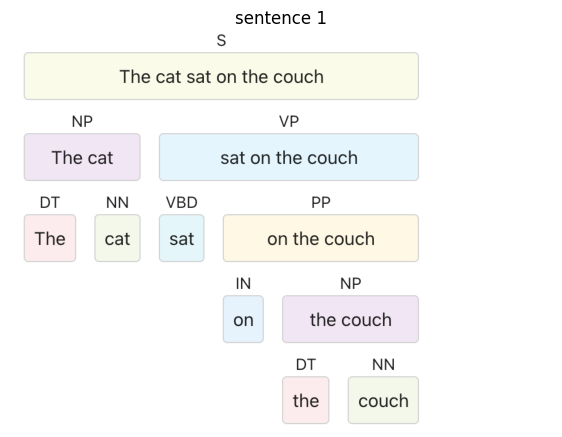

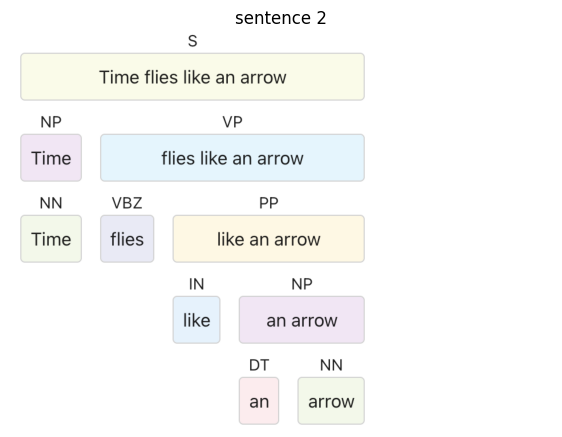

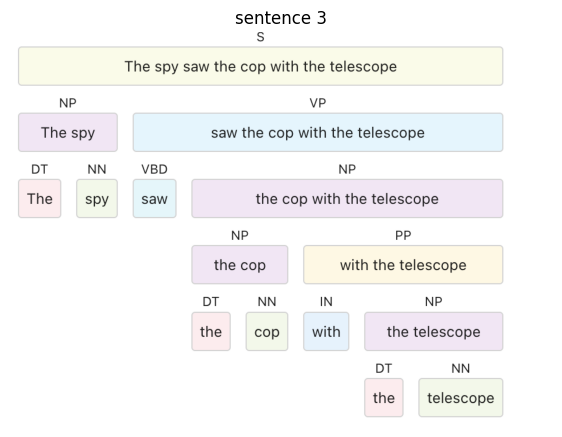

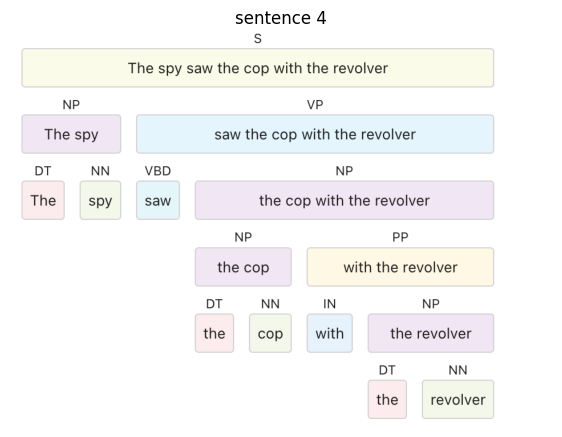

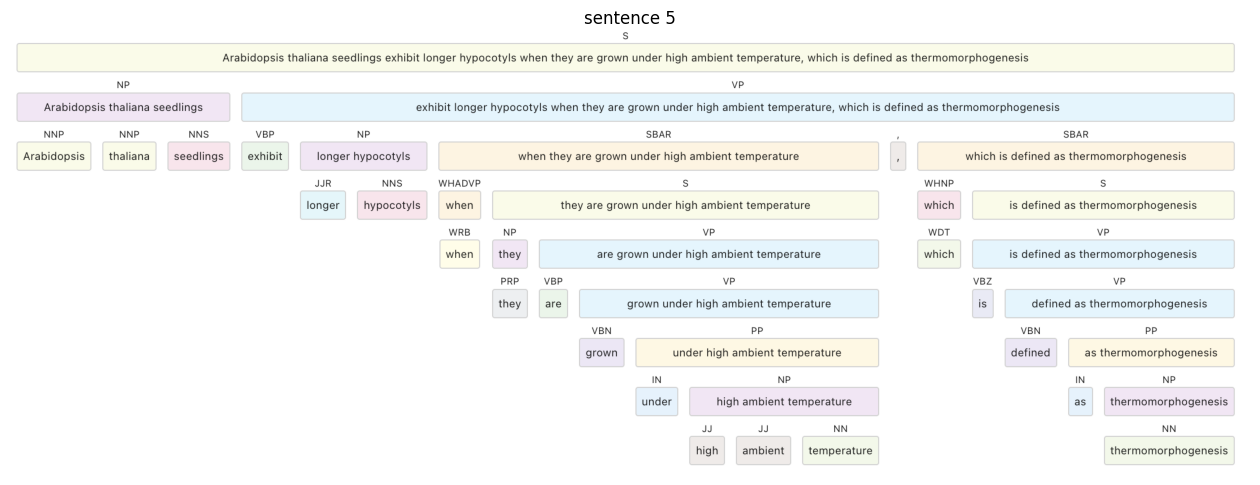

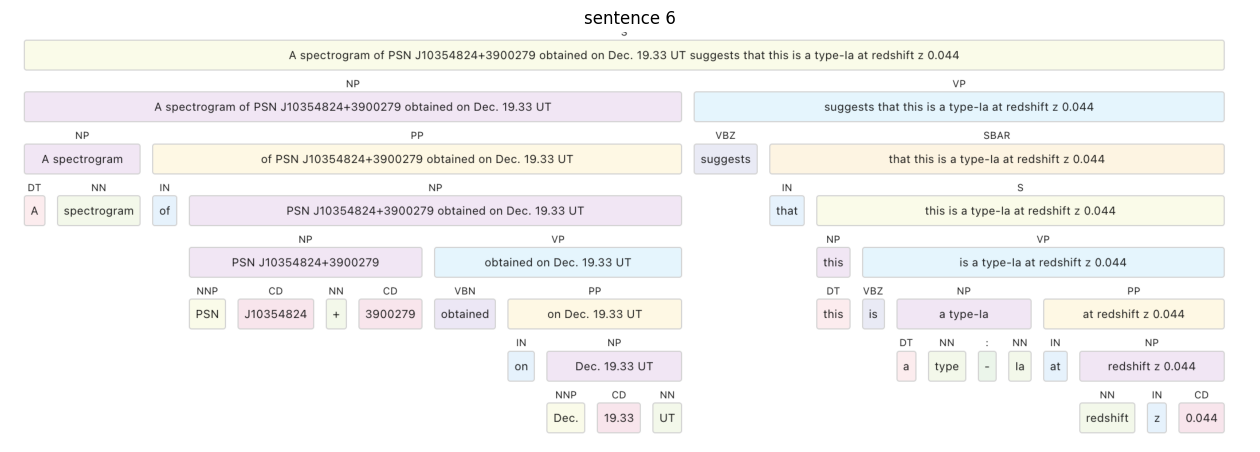

In [23]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

folder = Path("Berkeley_Neural_Parser")

for path in sorted(folder.iterdir()):

    if path.stem in {"sentence_5", "sentence_6"}:
        size = (16, 16)
    else:
        size = (7, 7)
        
    plt.figure(figsize=size)
    plt.imshow(Image.open(path))
    plt.title(path.stem.replace("_", " "))
    plt.axis("off")
    plt.show()

**Reading of 2.4.**

- **Benepar returns only one tree for each sentence.** 

In contrast, our grammar produces **2** analyses for each spy sentence and **354** and **2681** parses for the two specialty sentences. Benepar doesn't expose these alternative structures, since it selects a single preferred parse. For *Time flies like an arrow.*, for example, it returns only the well-known expression interpretation and does not show the alternative reading.


- **Benepar gives the same structure to both *telescope* and *revolver*.** 

In the packaged model, the PP is attached to the verb phrase, as in `(VP (VBD saw) (NP the cop) (PP with …))`. This corresponds to the interpretation in which the spy uses the object to see the cop, equivalent to our `VP → VP PP` analysis from Section 1.3. Futhermore, it makes that choice for *both* sentences, so the change of noun has no effect on the analysis.

Also, the online demo behaves differently: it attaches the PP inside the object noun phrase, corresponding to `NP → NP PP`, where the cop is interpreted as having the object. However, it again makes the same choice for both sentences.

In other words, the two Benepar versions prefer different attachments, but neither changes its analysis according to whether the noun is *telescope* or *revolver*. A person, by contrast, is much more likely to prefer a different interpretation depending on the noun.


- **Benepar uses a richer set of syntactic categories than our grammar allows.** 

Its analyses include labels such as `SBAR` ×2, `WHADVP`, `WHNP` and `NML`, as well as flat rules with more than two children, such as `VP → VBD NP PP`, which are not in Chomsky Normal Form.

As a result, some structures produced by Benepar cannot be represented directly using only `S`, `NP`, `VP` and `PP`. This confirms the limitation discussed in Section 1.5

- **Benepar also supports two of our annotation choices over the spaCy outputs.** 

It tags `flies` as `VBZ`, confirming that it functions as a verb, and `longer` as `JJR`, supporting our interpretation of it as a comparative adjective. It also attaches the relative clause low, to *high ambient temperature*, exactly as `G_SPEC` does.

- **Benepar disagrees with our annotation of the scientific binomial.** 

It tags *Arabidopsis thaliana* as `NNS NN`, treating both words as common nouns. In this case, its analysis is closer to the two spaCy models than to our `PROPN PROPN` gold annotation. It also tags `this` as `DT` and `J10354824` as `CD`.


# Part 3 — Observations

### 3.1 On PoS tagging

- **The general-purpose model performs better overall than the biomedical model, even on the biology sentence.** 

Across the evaluated sentences, `en_core_web_sm` reaches an average accuracy of **0.922**, compared with **0.885** for `en_core_sci_sm`. The same pattern appears in the biology sentence, where the general model obtains **0.810** accuracy versus **0.762** for the scientific model. This is somewhat unexpected, since we initially assumed that the domain-specific model would perform better on scientific text. However, sciSpaCy is mainly designed to improve biomedical tokenisation and named-entity processing, rather than necessarily providing better PoS tagging. Its PoS component is also trained on different resources and annotation conventions, which makes a direct comparison less straightforward.


- **The main source of disagreement comes from annotation conventions rather than clear tagging mistakes.** 

The most frequent confusion for both models is `PROPN → NOUN`, with three occurrences for `web_sm` and two for `sci_sm`. In these cases, the difference is largely due to how proper nouns are defined. The taggers generally follow the UD convention, where `PROPN` is used for names that refer to specific entities. For example, `web_sm` tags `PSN`, `J10354824`, `Dec.` and `UT` as `PROPN`, while `Arabidopsis`, `thaliana` and `Ia` are tagged as `NOUN`.

Our gold annotation follows a slightly different criterion. We treat formal scientific names, such as the Latin binomial *Arabidopsis thaliana*, as proper names and therefore label them as `PROPN`. The Berkeley parser, however, also analyses *Arabidopsis thaliana* as `NNS NN`, which is closer to the output of the automatic taggers.

This suggests that some of the apparent errors are actually differences between annotation schemes. Therefore, accuracy against a manually created gold standard does not measure tagging quality alone; it also reflects how closely the model's annotation conventions match those used in the gold annotation.


- **Some model errors really are errors.** 

For example, both models tag `longer` as `ADV`, even though in this sentence it modifies *hypocotyls* and functions as a comparative adjective. The Berkeley parser labels it as `JJR`, which supports our `ADJ` annotation (Section 2.4).

Likewise `hypocotyls` tagged `ADJ`, `redshift` tagged `NUM` and `z` tagged `PUNCT` by `sci_sm` are plain failures on unfamiliar vocabulary  which is precisely where a domain-specific model was supposed to help.

- **Tokenisation also affects the comparison, and this is where the scientific model differs most.** 

In the astronomy sentence, `sci_sm` treats `type-Ia` as a single token, while both `web_sm` and our gold annotation split it into three. As a result, `sci_sm` produces 23 tokens instead of 25.

Because the token sequences no longer align, the astronomy sentence cannot be evaluated directly for `sci_sm` using the same token-level metrics. This also means that the overall scores are based on different numbers of tokens: **52 tokens** for `sci_sm` compared with **77** for `web_sm`. Therefore, tokenisation differences need to be taken into account before comparing the PoS tagging results themselves.

### 3.2 On grammars and CYK


- **Ambiguity can arise in two different ways.** 

Structural ambiguity occurs when the same sequence of PoS tags can be grouped into different syntactic structures. This is what happens in the two spy sentences, where the grammar produces exactly two possible parses (Section 1.3). Lexical ambiguity, on the other hand, appears when a single token can have more than one possible PoS tag, as in *Time flies like an arrow.* (Section 1.4).

The CYK algorithm can handle both cases within the same framework because each token can be associated with a list of possible tags. This allows the parser to generate alternative analyses arising from either structural or lexical ambiguity.


- **A context-free grammar can tell us which structures are possible, but not which one is more plausible.** 

This is especially clear in the two spy sentences: our grammar produces the same two parse trees for *...with the telescope* and *...with the revolver*, even though a human reader tends to prefer a different interpretation in each case.

The CFG treats both structures as grammatically valid, but it has no information about the meaning of *telescope* or *revolver*, or about how these objects are typically used. Choosing the most natural interpretation therefore requires lexical and world knowledge beyond the grammar itself.


- **Coverage is bought with ambiguity, and the exchange rate is brutal.**

The `G_CORE` grammar cannot parse the specialty sentences because seven of the twelve PoS tags used in them cannot be reached from the start symbol. As a result, the parser returns `0` trees, and this would still be the case even with perfect PoS tagging (Section 1.5, Test 1).

Extending the grammar solves the coverage problem, but initially creates a very large number of possible parses: **3364** for the biology sentence and **30960** for the astronomy sentence (Test 2) where much of this ambiguity is spurious. As is shown in the *Arabidopsis thaliana seedlings* analysis, alone can be derived in five different ways without changing its meaning.

By rewriting the grammar to use a consistent branching direction, the number of analyses drops to **354** and **2681**, while preserving the constructions needed to parse both sentences. The ambiguity that remains is mainly genuine attachment ambiguity: in a 25-token sentence there are simply manyplaces for a modifier to attach.


- **We use two separate grammars, but not because combining them would break the general-domain sentences.** 

Adding the specialty rules to `G_CORE` leaves the number of parses for the general sentences unchanged at `1, 1, 2, 2`, because those additional rules depend on tags that do not appear in the general-domain examples.

The main reason for keeping the grammars separate is interpretability. In `G_CORE`, obtaining two parses usually corresponds to two genuinely different readings of a sentence. In the specialty grammar, however, a result such as **2681 parses** mainly reflects the large number of possible attachment points in a longer and more complex sentence. Keeping the two grammars separate therefore makes the parse counts easier to interpret within their respective contexts.



- **Restricting the grammar to `S`, `NP`, `VP` and `PP` also has consequences.** 

Without categories such as `SBAR`, several structures have to be represented indirectly. For example, subordinate clauses, the `+` and `-` symbols, and the comma before a relative clause are handled using rules such as `PP → SCONJ S`, `PP → PUNCT NP` and `PP → SYM NP`.

Section 2.4 shows this limitation more clearly when we compare our grammar with the Berkeley parser. On the same sentences, Berkeley uses additional categories such as `SBAR`, `WHNP`, `WHADVP` and `NML`, as well as flat rules with more than two children that are not in Chomsky Normal Form.




### 3.3 On the interaction between the two — the main result

**PoS tagging accuracy does not directly predict parsing success.** 

Only four sentence–model pairs in our corpus contain tagging errors, but their effect on parsing is very different. In three cases, the parser loses all possible analyses because the incorrect tag prevents the grammar from building a valid structure. In the fourth case, many parses are still preserved.

This can be seen clearly with `web_sm`. On the biology sentence, it achieves an accuracy of **0.810** but reduces the number of parses from **354 to 0**. On the astronomy sentence, its accuracy is only slightly higher, at **0.920**, yet **1318 of the original 2681 parses** remain. The difference in accuracy alone does not explain these very different outcomes. What matters is **which words are tagged incorrectly and what role they play in the grammar**.

* The most frequent confusion, `PROPN → NOUN`, has almost no effect on parsing. The number of analyses remains **354** and **2681**, because the grammar can use both both tags as ordinary nominals.

* An error on a **head** can be much more damaging. When `flies` is tagged as `NOUN`, the sentence *Time flies like an arrow.* loses its only verbal head and the number of parses drops from 1 to 0. Similarly, tagging `hypocotyls` as `ADJ` leaves the object noun phrase headles causing the biology sentence to fail completely.

* A tag that is **outside of the grammar** can have the same effect, even when the tag itself is linguistically reasonable. Examples include `ADV` for *longer* or `CCONJ` for `+`, where our grammar expects `SYM`.

This shows that standard metrics such as accuracy, precision and F1 do not capture the downstream importance of individual tagging errors. A frequent disagreement may have no effect on parsing, while a single error on a crucial token can make the whole sentence unparsable.

**A trained parser does not necessarily remove this ambiguity; it often selects one analysis instead.** The Berkeley parser returns a single tree where our grammar may return two, and it gives the same structural analysis to the *telescope* and *revolver* sentences despite their different preferred interpretations. It also does not expose the alternative reading of *Time flies like an arrow.* In addition, the packaged Berkeley model and the online demo do not always choose the same PP attachment.


Finaly, our pipeline is far weaker in grammar coverage than a trained parser, but it is the one that makes the ambiguity (the actual object of study) visible.
